当前工作目录: /home/huyang24/Y_ht/grad/UNET实验
模型目录: /home/huyang24/Y_ht/grad/UNET实验/google_cifar10
设备: cuda


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

===== Pipeline =====
DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.25.0",
  "_name_or_path": "google_cifar10",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}


===== UNet / Denoiser Structure =====
UNet2DModel(
  (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): LoRACompatibleLinear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): LoRACompatibleLinear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (conv1): LoRACompatibleConv(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): LoRACompatibleLinear(in_features=512, out_features=128, bias

  0%|          | 0/1000 [00:00<?, ?it/s]


生成图片数量: 10
单张图片尺寸: (32, 32)


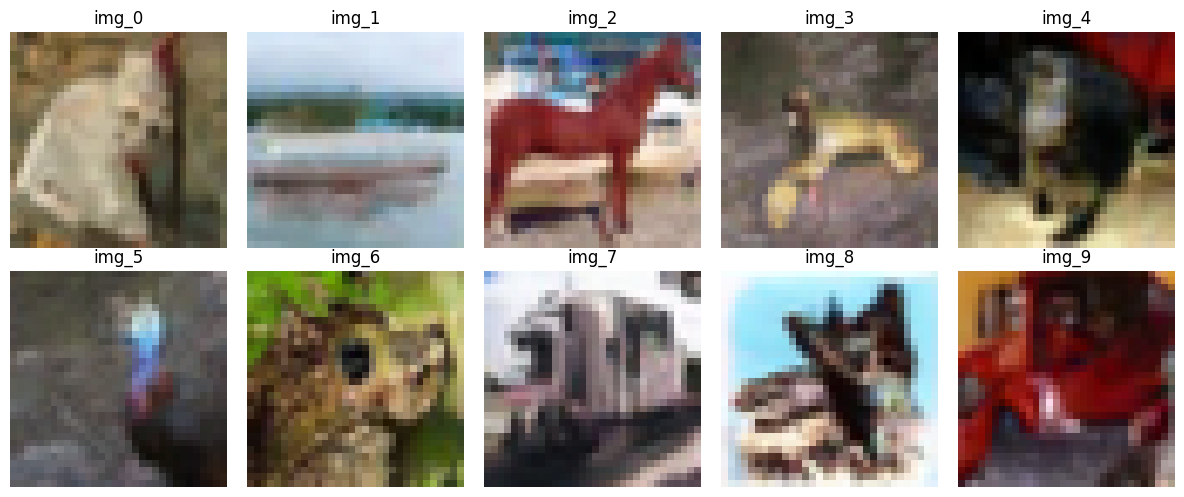

In [2]:
#pip install diffusers==0.25.0 "huggingface_hub<0.25.0" accelerate torchvision tqdm matplotlib
import os
import math
import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline

# -------------------------
# config
# -------------------------
model_dir = "google_cifar10"
device = "cuda" if torch.cuda.is_available() else "cpu"
num_images = 10
seed = 42

print("当前工作目录:", os.getcwd())
print("模型目录:", os.path.abspath(model_dir))
print("设备:", device)

# -------------------------
# load pipeline
# -------------------------
pipe = DDPMPipeline.from_pretrained(model_dir)
pipe = pipe.to(device)

# -------------------------
# print structure
# -------------------------
print("===== Pipeline =====")
print(pipe)

print("\n===== UNet / Denoiser Structure =====")
print(pipe.unet)

print("\n===== Scheduler =====")
print(pipe.scheduler)

total_params = sum(p.numel() for p in pipe.unet.parameters())
trainable_params = sum(p.numel() for p in pipe.unet.parameters() if p.requires_grad)

print(f"\n总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")

# -------------------------
# inference
# -------------------------
generator = torch.Generator(device=device).manual_seed(seed)

images = pipe(
    batch_size=num_images,
    generator=generator
).images

print(f"\n生成图片数量: {len(images)}")
print(f"单张图片尺寸: {images[0].size}")

# -------------------------
# show in notebook
# -------------------------
cols = 5
rows = math.ceil(num_images / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 5))
axes = axes.flatten()

for i in range(len(axes)):
    axes[i].axis("off")
    if i < num_images:
        axes[i].imshow(images[i])
        axes[i].set_title(f"img_{i}")

plt.tight_layout()
plt.show()




In [10]:
# -*- coding: utf-8 -*-
# ============================================================
# 实验目标（按你的要求对齐）
# 1. 使用 4 个配置 cfg1/cfg2/cfg3/cfg4 顺序运行 4 次实验。
# 2. 不再做两两时间对比较，而是：time_list 中每个时间 t 都和锚点 time_anchor 比较。
# 3. 模型不更新参数，只在“训练式前向”里求参数梯度方向；不做 optimizer.step()。
# 4. 支持 same_noise / different_noise：
#    - same_noise=True：同一张图在不同 t 使用同一个 epsilon 的加权版本
#    - same_noise=False：同一张图在不同 t 分别重新采样 epsilon
# 5. 只需要训练式求梯度，不需要生成图片。
# 6. compute_bias=None 表示只比较 weight 梯度；skip_norm_layers=True、skip_time_embedding=True 生效。
# 7. 层顺序按 UNet 主干逻辑顺序：Encoder -> Bottleneck -> Decoder。
# 8. 先打印模型所有层，再打印实际参与比较的层。
# 9. 用 Plotly 画两张英文图：
#    - mean cosine similarity
#    - mean absolute cosine similarity
#    其中瓶颈层用红色区域强调。
# 10. 每个 cfg 单独保存到不同目录：配置、层列表、样本图、结果日志、HTML 图。
# 11. 每次实验结束后清理缓存。
# 12. 模型结构从你本地 diffusers 目录读取：
#     - use_pretrained_weights=True：加载结构+权重
#     - use_pretrained_weights=False：只加载结构，不加载权重（随机初始化）
# ============================================================

import os
import gc
import json
import random
from dataclasses import dataclass
from collections import OrderedDict
from typing import List, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import CIFAR10
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import plotly.graph_objects as go
import plotly.io as pio

from diffusers import UNet2DModel, DDPMScheduler, DDPMPipeline


# ============================================================
# 0. 你的本地 diffusers 模型目录
# 如果你的可用代码里是这样加载成功的：
#   model_dir = "google_cifar10"
# 那么这里也必须保持一致。
# 不要写成 "."，除非你当前工作目录本身就是那个模型目录。
# ============================================================
MODEL_DIR = "google_cifar10"


# ============================================================
# 1. 基础设置
# ============================================================
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

try:
    pio.renderers.default = "notebook_connected"
except Exception:
    pass


def get_device() -> torch.device:
    return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


def print_gpu_info() -> None:
    if not torch.cuda.is_available():
        print("[GPU] CUDA 不可用，当前使用 CPU")
        return
    print(f"[GPU] 可见 GPU 数量: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"  - cuda:{i} | {props.name} | total={props.total_memory / 1024**3:.2f} GB")


DEVICE = get_device()
print(f"[DEVICE] {DEVICE}")
print(f"[MODEL_DIR] {os.path.abspath(MODEL_DIR)}")
print_gpu_info()


# ============================================================
# 2. 配置类
# ============================================================
@dataclass
class CFG:
    exp_name: str
    model_dir: str = MODEL_DIR
    use_pretrained_weights: bool = False

    # 时间设置：time_list = range(time_start, time_end+1, time_step)
    time_anchor: int = 0
    time_start: int = 0
    time_end: int = 900
    time_step: int = 100

    # 数据设置
    data_root: str = "/data/cifar-10"
    data_size: int = 1000
    batch_size: int = 16
    num_workers: int = 4
    pin_memory: bool = True
    persistent_workers: bool = True
    sample_index_to_show: int = 0

    # 噪声模式
    same_noise: bool = True

    # 输出目录
    save_root: str = "results/grad_compare_anchor"

    # 随机种子
    init_seed: int = 123456
    noise_seed: int = 2026

    # 梯度筛选
    only_param_suffixes: Optional[List[str]] = None
    compute_bias: Optional[bool] = None   # None=只比较 weight；True=weight+bias
    skip_norm_layers: bool = True
    skip_time_embedding: bool = True
    keep_only_unet_main_blocks: bool = True
    layers: Optional[List[str]] = None

    @property
    def time_list(self) -> List[int]:
        return list(range(self.time_start, self.time_end + 1, self.time_step))

    @property
    def compare_times(self) -> List[int]:
        return [t for t in self.time_list if t != self.time_anchor]

    @property
    def save_dir(self) -> str:
        return os.path.join(self.save_root, self.exp_name)

    def to_dict(self):
        return {
            "exp_name": self.exp_name,
            "model_dir": self.model_dir,
            "use_pretrained_weights": self.use_pretrained_weights,
            "time_anchor": self.time_anchor,
            "time_start": self.time_start,
            "time_end": self.time_end,
            "time_step": self.time_step,
            "time_list": self.time_list,
            "compare_times": self.compare_times,
            "data_root": self.data_root,
            "data_size": self.data_size,
            "batch_size": self.batch_size,
            "num_workers": self.num_workers,
            "pin_memory": self.pin_memory,
            "persistent_workers": self.persistent_workers,
            "sample_index_to_show": self.sample_index_to_show,
            "same_noise": self.same_noise,
            "save_root": self.save_root,
            "save_dir": self.save_dir,
            "init_seed": self.init_seed,
            "noise_seed": self.noise_seed,
            "only_param_suffixes": self.only_param_suffixes,
            "compute_bias": self.compute_bias,
            "skip_norm_layers": self.skip_norm_layers,
            "skip_time_embedding": self.skip_time_embedding,
            "keep_only_unet_main_blocks": self.keep_only_unet_main_blocks,
            "layers": self.layers,
        }


# 四组实验：随机初始化 / 预训练 × same_noise / different_noise
cfg1 = CFG(
    exp_name="exp1_random_init_same_noise",
    use_pretrained_weights=False,
    same_noise=True,
)
cfg2 = CFG(
    exp_name="exp2_pretrained_same_noise",
    use_pretrained_weights=True,
    same_noise=True,
)
cfg3 = CFG(
    exp_name="exp3_random_init_different_noise",
    use_pretrained_weights=False,
    same_noise=False,
)
cfg4 = CFG(
    exp_name="exp4_pretrained_different_noise",
    use_pretrained_weights=True,
    same_noise=False,
)
CFG_LIST = [cfg1, cfg2, cfg3, cfg4]


# ============================================================
# 3. 数据集
# ============================================================
class CIFAR10Deterministic(Dataset):
    def __init__(self, root: str, train: bool = True):
        self.ds = CIFAR10(
            root=root,
            train=train,
            download=False,
            transform=transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
            ]),
        )

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx: int):
        img, _ = self.ds[idx]
        return img


# ============================================================
# 4. 工具函数
# ============================================================
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def save_json(obj, path: str) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def denorm_to_show(x: torch.Tensor) -> np.ndarray:
    x = x.detach().cpu().float()
    x = x * 0.5 + 0.5
    x = x.clamp(0.0, 1.0)
    x = x.permute(1, 2, 0).numpy()
    return x


def save_sample_image(dataset: Dataset, sample_index: int, save_dir: str) -> None:
    os.makedirs(save_dir, exist_ok=True)
    img = dataset[sample_index]
    img_vis = denorm_to_show(img)
    plt.figure(figsize=(3.2, 3.2))
    plt.imshow(img_vis)
    plt.axis("off")
    plt.title(f"Sample #{sample_index}")
    save_path = os.path.join(save_dir, "sample_image.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"[SAVE] sample image -> {save_path}")


def unwrap_model(model: nn.Module) -> nn.Module:
    return model.module if isinstance(model, nn.DataParallel) else model


# ============================================================
# 5. 构建模型与 scheduler
# 关键：不再手写 down_block_types / up_block_types
#      直接读取你本地目录里的 config.json / 权重
# ============================================================
def build_model_and_scheduler(cfg: CFG, device: torch.device):
    if cfg.use_pretrained_weights:
        pipe = DDPMPipeline.from_pretrained(cfg.model_dir)
        model = pipe.unet
        scheduler = pipe.scheduler
        model_info_text = f"pretrained from local diffusers directory: {os.path.abspath(cfg.model_dir)}"
        print("[MODEL] 结构 + 权重：已从本地目录加载")
    else:
        unet_config = UNet2DModel.load_config(cfg.model_dir)
        model = UNet2DModel.from_config(unet_config)
        scheduler = DDPMScheduler.from_pretrained(cfg.model_dir)
        model_info_text = f"random initialized from local config only: {os.path.abspath(cfg.model_dir)}"
        print("[MODEL] 只加载结构配置：随机初始化，不加载预训练权重")

    model = model.to(device)
    model.eval()

    if torch.cuda.is_available() and torch.cuda.device_count() > 1:
        print(f"[MODEL] 使用 DataParallel，GPU 数量 = {torch.cuda.device_count()}")
        model = nn.DataParallel(model)

    return model, scheduler, model_info_text


# ============================================================
# 6. 层筛选与排序
# ============================================================
NORMALIZATION_TYPES = (
    nn.BatchNorm1d,
    nn.BatchNorm2d,
    nn.BatchNorm3d,
    nn.SyncBatchNorm,
    nn.GroupNorm,
    nn.LayerNorm,
    nn.InstanceNorm1d,
    nn.InstanceNorm2d,
    nn.InstanceNorm3d,
)
if hasattr(nn, "RMSNorm"):
    NORMALIZATION_TYPES = NORMALIZATION_TYPES + (nn.RMSNorm,)


def classify_unet_main_stage(layer_name: str) -> Optional[str]:
    if layer_name == "conv_in" or layer_name.startswith("down_blocks"):
        return "encoder"
    if layer_name.startswith("mid_block"):
        return "bottleneck"
    if layer_name.startswith("up_blocks") or layer_name.startswith("conv_norm_out") or layer_name.startswith("conv_out"):
        return "decoder"
    return None


def is_time_related_layer(layer_name: str) -> bool:
    time_keywords = ["time_proj", "time_embedding", "temb", "add_embedding", "class_embedding"]
    return any(k in layer_name for k in time_keywords)


def suffix_allowed(name: str, allowed_suffix) -> bool:
    if allowed_suffix is None:
        return True
    if isinstance(allowed_suffix, str):
        return name.endswith(allowed_suffix)
    if isinstance(allowed_suffix, (list, tuple, set)):
        return any(name.endswith(suf) for suf in allowed_suffix)
    raise TypeError("allowed_suffix 只能是 None / str / list / tuple / set")


def build_layer_param_groups(model: nn.Module, cfg: CFG):
    base_model = unwrap_model(model)
    grouped = OrderedDict()

    skipped_norm_layers = set()
    skipped_time_layers = set()
    skipped_non_main_layers = set()

    for name, param in base_model.named_parameters():
        if not param.requires_grad:
            continue

        # compute_bias=None -> 只看权重
        if cfg.compute_bias is None and name.endswith(".bias"):
            continue

        if not suffix_allowed(name, cfg.only_param_suffixes):
            continue

        layer_name = name.rsplit(".", 1)[0] if "." in name else name

        if cfg.skip_time_embedding and is_time_related_layer(layer_name):
            skipped_time_layers.add(layer_name)
            continue

        stage = classify_unet_main_stage(layer_name)
        if cfg.keep_only_unet_main_blocks and stage is None:
            skipped_non_main_layers.add(layer_name)
            continue

        if cfg.skip_norm_layers:
            try:
                module = base_model.get_submodule(layer_name)
            except Exception:
                module = None
            if module is not None and isinstance(module, NORMALIZATION_TYPES):
                skipped_norm_layers.add(layer_name)
                continue

        if cfg.layers is not None and not any(k in layer_name for k in cfg.layers):
            continue

        if layer_name not in grouped:
            grouped[layer_name] = {
                "param_names": [],
                "stage": stage,
            }
        grouped[layer_name]["param_names"].append(name)

    ordered_items = []
    for target_stage in ["encoder", "bottleneck", "decoder"]:
        for layer_name, item in grouped.items():
            if item["stage"] == target_stage:
                ordered_items.append((layer_name, item))

    if not cfg.keep_only_unet_main_blocks:
        for layer_name, item in grouped.items():
            if item["stage"] is None:
                ordered_items.append((layer_name, item))

    layer_names = []
    selected_param_names = []
    layer_param_name_groups = []
    is_mid_flags = []
    stage_names = []

    for layer_name, item in ordered_items:
        layer_names.append(layer_name)
        selected_param_names.extend(item["param_names"])
        layer_param_name_groups.append(item["param_names"])
        is_mid_flags.append(item["stage"] == "bottleneck")
        stage_names.append(item["stage"])

    print("\n" + "=" * 120)
    print("Selected layers for cosine comparison (ordered):")
    for i, (layer_name, stage) in enumerate(zip(layer_names, stage_names)):
        print(f"[{i:03d}] {stage:<10s} | {layer_name}")
    print("=" * 120 + "\n")

    print(f"[LAYER] selected={len(layer_names)}")
    print(f"[LAYER] skipped norm={len(skipped_norm_layers)}")
    print(f"[LAYER] skipped time embedding={len(skipped_time_layers)}")
    print(f"[LAYER] skipped non-main={len(skipped_non_main_layers)}")

    return layer_names, selected_param_names, layer_param_name_groups, is_mid_flags, stage_names


def build_layer_slices(layer_param_name_groups):
    layer_slices = []
    start = 0
    for group in layer_param_name_groups:
        end = start + len(group)
        layer_slices.append((start, end))
        start = end
    return layer_slices


def save_layer_list_txt(layer_names, stage_names, save_path: str) -> None:
    with open(save_path, "w", encoding="utf-8") as f:
        for i, (layer_name, stage) in enumerate(zip(layer_names, stage_names)):
            f.write(f"[{i:03d}] {stage:<10s} | {layer_name}\n")


# ============================================================
# 7. 噪声与梯度计算
# 注意：这里只是在做训练式前向，不是生成图片
# ============================================================
def make_noise_like(clean_img_1: torch.Tensor, seed: int) -> torch.Tensor:
    # 为了彻底避免把 torch.Generator 对象误传成噪声 Tensor，
    # 这里每次都用一个局部 generator 直接生成 Tensor，然后返回 Tensor。
    # 这样后面 noise_1 一定是张量，不可能是 generator 对象。
    gen = torch.Generator(device="cpu")
    gen.manual_seed(int(seed))
    noise = torch.randn(
        clean_img_1.shape,
        generator=gen,
        dtype=clean_img_1.dtype,
        device="cpu",
    )
    return noise.to(clean_img_1.device)


def get_noise_for_sample_time(clean_img_1: torch.Tensor,
                              base_seed: int,
                              global_sample_idx: int,
                              timestep: int,
                              same_noise: bool) -> torch.Tensor:
    # same_noise=True: 同一张图在所有 t 上都使用同一个 epsilon
    # same_noise=False: 同一张图在不同 t 上用不同 epsilon
    if same_noise:
        seed = int(base_seed) + int(global_sample_idx)
    else:
        seed = int(base_seed) + int(global_sample_idx) * 10000 + int(timestep)
    return make_noise_like(clean_img_1, seed)


def compute_single_sample_grads(model: nn.Module,
                                scheduler: DDPMScheduler,
                                clean_img_1: torch.Tensor,
                                noise_1,
                                timestep_1: int,
                                selected_params):
    if not torch.is_tensor(clean_img_1):
        raise TypeError(f"clean_img_1 必须是 Tensor，当前类型={type(clean_img_1)}")

    # 兼容误把 torch.Generator 传进来的情况：在这里显式采样成噪声 Tensor
    if isinstance(noise_1, torch.Generator):
        noise_1 = torch.randn(
            clean_img_1.shape,
            generator=noise_1,
            dtype=clean_img_1.dtype,
            device="cpu",
        ).to(clean_img_1.device)
    elif not torch.is_tensor(noise_1):
        raise TypeError(f"noise_1 必须是 Tensor（或 torch.Generator），当前类型={type(noise_1)}")

    t = torch.tensor([int(timestep_1)], device=clean_img_1.device, dtype=torch.long)
    noisy = scheduler.add_noise(clean_img_1, noise_1, t)
    pred = model(noisy, t).sample

    if pred.shape != noise_1.shape:
        raise ValueError(f"pred 与 noise_1 形状不一致: pred={tuple(pred.shape)}, noise_1={tuple(noise_1.shape)}")

    loss = F.mse_loss(pred, noise_1, reduction="mean")

    grads = torch.autograd.grad(
        outputs=loss,
        inputs=selected_params,
        retain_graph=False,
        create_graph=False,
        allow_unused=False,
    )
    return grads, float(loss.item())


def layerwise_cosine_from_two_grad_lists(grads_a, grads_b, layer_slices, device, eps: float = 1e-12):
    L = len(layer_slices)
    cos_vec = torch.empty((L,), device=device, dtype=torch.float32)

    for i, (s, e) in enumerate(layer_slices):
        dot = torch.tensor(0.0, device=device)
        n1 = torch.tensor(0.0, device=device)
        n2 = torch.tensor(0.0, device=device)

        for g1, g2 in zip(grads_a[s:e], grads_b[s:e]):
            v1 = g1.reshape(-1).float()
            v2 = g2.reshape(-1).float()
            dot += torch.dot(v1, v2)
            n1 += torch.dot(v1, v1)
            n2 += torch.dot(v2, v2)

        both_zero = bool((n1 < eps).item() and (n2 < eps).item())
        one_zero = bool(((n1 < eps).item()) ^ ((n2 < eps).item()))

        if both_zero:
            cos_vec[i] = 1.0
        elif one_zero:
            cos_vec[i] = 0.0
        else:
            cos_vec[i] = dot / (torch.sqrt(n1) * torch.sqrt(n2) + eps)

    return cos_vec


def finalize_mean_metric(sum_metric: torch.Tensor, count: torch.Tensor) -> torch.Tensor:
    mean_metric = torch.full_like(sum_metric, float("nan"), dtype=torch.float64)
    valid = count > 0
    mean_metric[valid] = sum_metric[valid] / count[valid].to(sum_metric.dtype)
    return mean_metric


# ============================================================
# 8. Plotly 绘图
# ============================================================
def build_stage_ranges(stage_names):
    ranges = []
    if len(stage_names) == 0:
        return ranges
    start = 0
    cur = stage_names[0]
    for i in range(1, len(stage_names)):
        if stage_names[i] != cur:
            ranges.append((cur, start, i - 1))
            start = i
            cur = stage_names[i]
    ranges.append((cur, start, len(stage_names) - 1))
    return ranges


def plot_anchor_curve(compare_time: int,
                      layer_names,
                      mean_metric,
                      is_mid_flags,
                      stage_names,
                      save_dir: str,
                      model_info_text: str,
                      time_anchor: int,
                      metric_mode: str = "signed") -> None:
    x = list(range(len(layer_names)))
    stage_ranges = build_stage_ranges(stage_names)
    customdata = np.array(list(zip(layer_names, stage_names)), dtype=object)

    if metric_mode == "signed":
        title_mode = "Mean Cosine Similarity"
        y_title = "Cosine Similarity"
        save_name = f"anchor_{time_anchor}_vs_{compare_time}_signed.html"
        y_range = [-1.05, 1.05]
    elif metric_mode == "abs":
        title_mode = "Mean Absolute Cosine Similarity"
        y_title = "Absolute Cosine Similarity"
        save_name = f"anchor_{time_anchor}_vs_{compare_time}_abs.html"
        y_range = [-0.05, 1.05]
    else:
        raise ValueError("metric_mode must be 'signed' or 'abs'")

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=x,
            y=mean_metric,
            mode="lines+markers",
            name=f"t={time_anchor} vs t={compare_time}",
            customdata=customdata,
            hovertemplate=(
                "Layer index=%{x}<br>"
                "Layer name=%{customdata[0]}<br>"
                "Stage=%{customdata[1]}<br>"
                f"{title_mode}=%{{y:.6f}}<extra></extra>"
            ),
        )
    )

    stage_fill = {
        "encoder": "rgba(70,130,180,0.08)",
        "bottleneck": "rgba(220,20,60,0.10)",
        "decoder": "rgba(46,139,87,0.08)",
    }

    for stage, s, e in stage_ranges:
        fig.add_vrect(
            x0=s - 0.5,
            x1=e + 0.5,
            fillcolor=stage_fill.get(stage, "rgba(0,0,0,0.03)"),
            opacity=1.0,
            line_width=0,
        )
        fig.add_annotation(
            x=(s + e) / 2.0,
            y=-0.16,
            xref="x",
            yref="paper",
            text=stage.capitalize(),
            showarrow=False,
            font=dict(size=15),
        )

    mid_indices = [i for i, flag in enumerate(is_mid_flags) if flag]
    if len(mid_indices) > 0:
        fig.add_vrect(
            x0=min(mid_indices) - 0.5,
            x1=max(mid_indices) + 0.5,
            fillcolor="rgba(255,0,0,0.10)",
            opacity=1.0,
            line_width=0,
        )
        fig.add_vline(
            x=(min(mid_indices) + max(mid_indices)) / 2.0,
            line_color="red",
            line_width=2,
        )

    for _, _, e in stage_ranges[:-1]:
        fig.add_vline(x=e + 0.5, line_color="gray", line_dash="dot", line_width=1)

    fig.update_layout(
        title=(
            f"Gradient Direction Similarity Across UNet Layers<br>"
            f"<sup>Anchor t={time_anchor} vs Compare t={compare_time} | {title_mode}<br>{model_info_text}</sup>"
        ),
        xaxis_title="UNet Layers (Encoder → Bottleneck → Decoder)",
        yaxis_title=y_title,
        template="plotly_white",
        width=1550,
        height=760,
        hovermode="x unified",
        margin=dict(l=70, r=40, t=120, b=120),
    )
    fig.update_yaxes(range=y_range)
    fig.update_xaxes(
        tickmode="array",
        tickvals=x[::max(1, len(x)//18)],
        ticktext=[str(i) for i in x[::max(1, len(x)//18)]],
    )

    save_path = os.path.join(save_dir, save_name)
    fig.write_html(save_path)
    print(f"[SAVE] plot -> {save_path}")
    fig.show(renderer=pio.renderers.default)


# ============================================================
# 9. 单个实验主函数
# ============================================================
def run_single_experiment(cfg: CFG):
    print("\n" + "#" * 120)
    print(f"Start experiment: {cfg.exp_name}")
    print("#" * 120)

    os.makedirs(cfg.save_dir, exist_ok=True)
    save_json(cfg.to_dict(), os.path.join(cfg.save_dir, "config_log.json"))

    set_global_seed(cfg.init_seed)

    dataset = CIFAR10Deterministic(cfg.data_root, train=True)
    n_samples = min(int(cfg.data_size), len(dataset))
    subset = Subset(dataset, list(range(n_samples)))

    pin_memory = bool(cfg.pin_memory) and torch.cuda.is_available()
    persistent_workers = bool(cfg.persistent_workers) and int(cfg.num_workers) > 0

    loader = DataLoader(
        subset,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
        drop_last=False,
    )

    save_sample_image(dataset, cfg.sample_index_to_show, cfg.save_dir)

    model, scheduler, model_info_text = build_model_and_scheduler(cfg, DEVICE)
    base_model = unwrap_model(model)

    print("\n" + "=" * 120)
    print("All named modules in model (registration order):")
    for i, (module_name, module_obj) in enumerate(base_model.named_modules()):
        if module_name == "":
            continue
        print(f"[{i:03d}] {module_name:<80s} | {module_obj.__class__.__name__}")
    print("=" * 120 + "\n")

    layer_names, selected_param_names, layer_param_name_groups, is_mid_flags, stage_names = build_layer_param_groups(model, cfg)
    save_layer_list_txt(layer_names, stage_names, os.path.join(cfg.save_dir, "ordered_layers.txt"))

    named_params = dict(base_model.named_parameters())
    selected_params = [named_params[name] for name in selected_param_names]
    layer_slices = build_layer_slices(layer_param_name_groups)

    results_buffer = {}
    for t in cfg.compare_times:
        results_buffer[int(t)] = {
            "sum_cos": torch.zeros(len(layer_names), device=DEVICE, dtype=torch.float64),
            "sum_abs_cos": torch.zeros(len(layer_names), device=DEVICE, dtype=torch.float64),
            "count": torch.zeros(len(layer_names), device=DEVICE, dtype=torch.int64),
            "anchor_loss_sum": 0.0,
            "compare_loss_sum": 0.0,
            "num_samples": 0,
        }
    global_sample_idx = 0

    pbar = tqdm(total=n_samples, desc=f"{cfg.exp_name} | gradient cosine")
    for clean_img in loader:
        clean_img = clean_img.to(DEVICE, non_blocking=pin_memory)
        B = clean_img.shape[0]
        for b in range(B):
            clean_img_1 = clean_img[b:b+1]

            noise_anchor = get_noise_for_sample_time(
                clean_img_1=clean_img_1,
                base_seed=cfg.noise_seed,
                global_sample_idx=global_sample_idx,
                timestep=cfg.time_anchor,
                same_noise=cfg.same_noise,
            )
            grads_anchor, anchor_loss_val = compute_single_sample_grads(
                model=model,
                scheduler=scheduler,
                clean_img_1=clean_img_1,
                noise_1=noise_anchor,
                timestep_1=cfg.time_anchor,
                selected_params=selected_params,
            )

            for t in cfg.compare_times:
                noise_t = get_noise_for_sample_time(
                    clean_img_1=clean_img_1,
                    base_seed=cfg.noise_seed,
                    global_sample_idx=global_sample_idx,
                    timestep=t,
                    same_noise=cfg.same_noise,
                )
                grads_t, loss_t_val = compute_single_sample_grads(
                    model=model,
                    scheduler=scheduler,
                    clean_img_1=clean_img_1,
                    noise_1=noise_t,
                    timestep_1=t,
                    selected_params=selected_params,
                )

                cos_vec = layerwise_cosine_from_two_grad_lists(
                    grads_a=grads_anchor,
                    grads_b=grads_t,
                    layer_slices=layer_slices,
                    device=DEVICE,
                )
                valid_mask = ~torch.isnan(cos_vec)

                results_buffer[int(t)]["sum_cos"] += torch.nan_to_num(cos_vec, nan=0.0).to(torch.float64)
                results_buffer[int(t)]["sum_abs_cos"] += torch.nan_to_num(cos_vec.abs(), nan=0.0).to(torch.float64)
                results_buffer[int(t)]["count"] += valid_mask.to(torch.int64)
                results_buffer[int(t)]["anchor_loss_sum"] += float(anchor_loss_val)
                results_buffer[int(t)]["compare_loss_sum"] += float(loss_t_val)
                results_buffer[int(t)]["num_samples"] += 1

            global_sample_idx += 1

        pbar.update(B)
    pbar.close()

    summary_log = {
        "exp_name": cfg.exp_name,
        "model_info_text": model_info_text,
        "time_anchor": cfg.time_anchor,
        "compare_times": cfg.compare_times,
        "same_noise": cfg.same_noise,
        "layer_count": len(layer_names),
        "curves": {},
    }

    final_results = {}
    for t in cfg.compare_times:
        sum_cos = results_buffer[int(t)]["sum_cos"]
        sum_abs_cos = results_buffer[int(t)]["sum_abs_cos"]
        count = results_buffer[int(t)]["count"]
        num_samples_t = max(1, int(results_buffer[int(t)]["num_samples"]))

        mean_cos = finalize_mean_metric(sum_cos, count).detach().cpu().numpy()
        mean_abs_cos = finalize_mean_metric(sum_abs_cos, count).detach().cpu().numpy()
        mean_anchor_loss = results_buffer[int(t)]["anchor_loss_sum"] / num_samples_t
        mean_compare_loss = results_buffer[int(t)]["compare_loss_sum"] / num_samples_t

        final_results[int(t)] = {
            "layer_names": layer_names,
            "stage_names": stage_names,
            "is_mid_flags": is_mid_flags,
            "mean_cos": mean_cos,
            "mean_abs_cos": mean_abs_cos,
            "mean_anchor_loss": mean_anchor_loss,
            "mean_compare_loss": mean_compare_loss,
            "model_info_text": model_info_text,
        }

        summary_log["curves"][str(t)] = {
            "mean_anchor_loss": mean_anchor_loss,
            "mean_compare_loss": mean_compare_loss,
            "signed_curve_first10": [float(x) for x in mean_cos[:10]],
            "abs_curve_first10": [float(x) for x in mean_abs_cos[:10]],
        }

        print("=" * 100)
        print(f"Anchor t={cfg.time_anchor} vs Compare t={t}")
        print(model_info_text)
        print(f"Mean loss @ anchor t={cfg.time_anchor}: {mean_anchor_loss:.6f}")
        print(f"Mean loss @ compare t={t}: {mean_compare_loss:.6f}")
        print("=" * 100)

        plot_anchor_curve(
            compare_time=t,
            layer_names=layer_names,
            mean_metric=mean_cos,
            is_mid_flags=is_mid_flags,
            stage_names=stage_names,
            save_dir=cfg.save_dir,
            model_info_text=model_info_text,
            time_anchor=cfg.time_anchor,
            metric_mode="signed",
        )
        plot_anchor_curve(
            compare_time=t,
            layer_names=layer_names,
            mean_metric=mean_abs_cos,
            is_mid_flags=is_mid_flags,
            stage_names=stage_names,
            save_dir=cfg.save_dir,
            model_info_text=model_info_text,
            time_anchor=cfg.time_anchor,
            metric_mode="abs",
        )

    save_json(summary_log, os.path.join(cfg.save_dir, "result_log.json"))
    print(f"[SAVE] result log -> {os.path.join(cfg.save_dir, 'result_log.json')}")

    del model
    del base_model
    del scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    print(f"[CLEAN] {cfg.exp_name} cache cleared")

    return final_results


# ============================================================
# 10. 跑四组实验
# ============================================================
def run_all_experiments(cfg_list: List[CFG]):
    all_results = {}
    for cfg in cfg_list:
        all_results[cfg.exp_name] = run_single_experiment(cfg)
    return all_results


# ============================================================
# 11. 开始运行
# ============================================================
all_results = run_all_experiments(CFG_LIST)


# ============================================================
# 12. 简要打印每个实验前 10 层结果
# ============================================================
for exp_name, exp_out in all_results.items():
    print("\n" + "#" * 120)
    print(f"Experiment = {exp_name}")
    print("#" * 120)
    for compare_t, out in exp_out.items():
        print(f"\n>>> Anchor t=0 vs Compare t={compare_t} | first 10 layers")
        for i, (name, val1, val2) in enumerate(zip(out["layer_names"][:10], out["mean_cos"][:10], out["mean_abs_cos"][:10])):
            print(f"[{i:02d}] {name:<70s} cos={val1:.6f} | abs_cos={val2:.6f}")


SyntaxError: invalid syntax (1417604464.py, line 482)